# Daños materiales, categorías y sexo: ámbitos y denominadores compatibles

Real published results from DGT, INE and Eurostat. Author: Javier Saguar.

See [methodology](../docs/methodology.md), [sources](../docs/sources.md) and [limitations](../docs/limitations.md).

Reusable implementations live in `src/`; reproduce artifacts using the CLI before rerunning these explorations.

In [1]:
from pathlib import Path
import json
import pandas as pd
from ebdi.metrics.index import composite
from ebdi.utils.io import read_yaml
ROOT = Path.cwd() if (Path.cwd() / "configs").exists() else Path.cwd().parent
TABLES = ROOT / "outputs/tables"
spain = pd.read_csv(TABLES / "spain_metrics.csv", dtype={"province_code": str})


## Irlanda: ocurrencia, exposición y liquidación son bases distintas

        category  ultimate_claims  earned_policies_all  frequency_per_1000_all_policies  mean_cost_eur  cost_per_policy_eur
Daños materiales    193329.185365         2.256122e+06                        85.690931    2236.243034           191.625747
        Lesiones     11724.636817         2.256122e+06                         5.196810   39537.147932           205.467046
           Total    205053.822182         2.256122e+06                        90.887741    4369.046793           397.092793
Ultimate estimates include nil-compensation claims; no Poisson intervals. Market coverage is by premium, not persons.


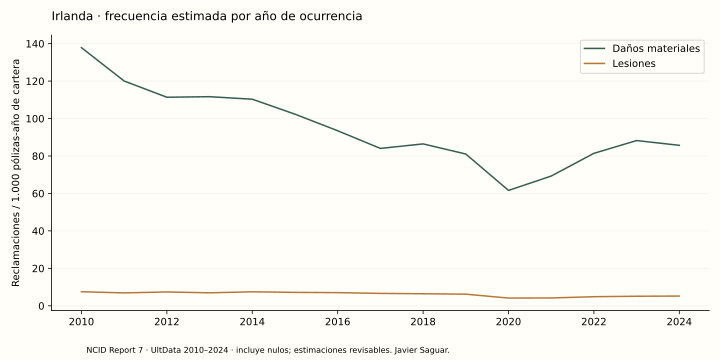

In [2]:
claims = pd.read_csv(TABLES / "ncid_ultimate.csv")
settled = pd.read_csv(TABLES / "ncid_settled.csv")
quality = json.loads((TABLES / "ncid_quality.json").read_text())
assert quality["matched_exposure_sheet"] == "UltData (not PremData)"
assert quality["table14_minus_table12_summary_2024"] == 18
assert not any("frequency" in column for column in settled)
latest = claims[(claims.year == 2024) & claims.category.isin(["Daños materiales", "Lesiones", "Total"])]
print(latest[["category", "ultimate_claims", "earned_policies_all", "frequency_per_1000_all_policies", "mean_cost_eur", "cost_per_policy_eur"]].to_string(index=False))
print("Ultimate estimates include nil-compensation claims; no Poisson intervals. Market coverage is by premium, not persons.")
from IPython.display import SVG, display
display(SVG(filename=str(ROOT / "outputs/figures/ncid_frequency.svg")))

## Inflación general frente a costes nominales; no atribución causal

 year         category  ultimate_claims_change_2019_pct  frequency_per_1000_all_policies_change_2019_pct  mean_cost_eur_change_2019_pct  mean_cost_2024_eur_change_2019_pct  cost_per_policy_eur_change_2019_pct
 2024 Daños materiales                        22.424683                                         5.730274                      75.181677                           49.212534                            85.220068


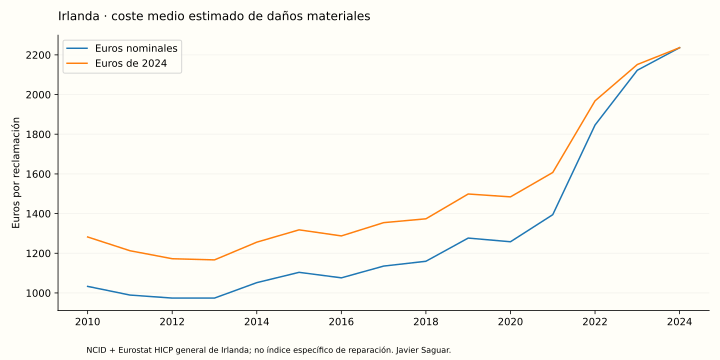

Fixed 2019 descriptive baseline; all-items Irish HICP, not a parts/labour price index.


In [3]:
changes = pd.read_csv(TABLES / "ncid_changes.csv")
print(changes[(changes.year == 2024) & changes.category.eq("Daños materiales")].to_string(index=False))
display(SVG(filename=str(ROOT / "outputs/figures/ncid_costs.svg")))
print("Fixed 2019 descriptive baseline; all-items Irish HICP, not a parts/labour price index.")

## Alemania: solo daños policiales y cobertura del registro

 year  total_crashes  injury_crashes  property_only_crashes  serious_property_crashes  fatalities  property_only_share_pct
 2010        2411271          288297                2122974                     92107        3648                88.043774
 2019        2685661          300143                2385518                     69189        3046                88.824241
 2020        2245245          264499                1980746                     58014        2719                88.219593
 2024        2512697          290701                2221996                     64039        2770                88.430718
 state                   location  year  total_crashes  injury_crashes  serious_property_crashes  intoxicant_property_crashes  other_property_crashes  property_only_crashes  property_only_share_pct
Berlin Interurbana sin autopistas  2024            NaN             NaN                       NaN                          NaN                     NaN                    NaN               

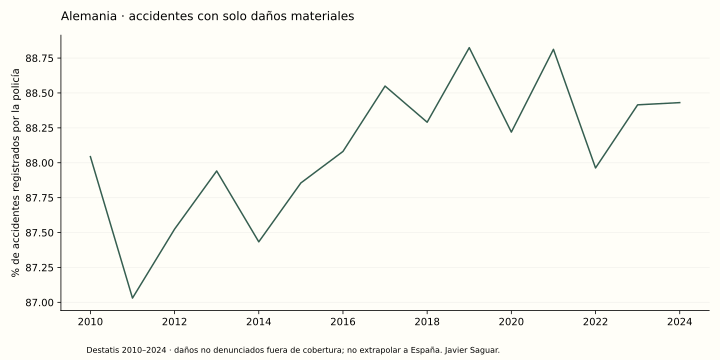

Missing Berlin rural cell retained. Reporting coverage differs from insurance claims; no Spain extrapolation.


In [4]:
history = pd.read_csv(TABLES / "material_history.csv")
states = pd.read_csv(TABLES / "material_states.csv")
assert history.total_crashes.eq(history.injury_crashes + history.property_only_crashes).all()
print(history[history.year.isin([2010, 2019, 2020, 2024])].to_string(index=False))
print(states[(states.state == "Berlin") & (states.location == "Interurbana sin autopistas")].to_string(index=False))
display(SVG(filename=str(ROOT / "outputs/figures/germany_property_share.svg")))
print("Missing Berlin rural cell retained. Reporting coverage differs from insurance claims; no Spain extrapolation.")

## España: sexo, edad, roles y ajuste con población común

 year sex  fatalities  population  crude_per_million     lower     upper  age_standardized_per_million  unknown_age_deaths                                                                                                                                                    standard
 2022   F       395.0  24198046.0          16.323632 14.753345 18.015551                     15.831549                 5.0 Fixed Spain M+F 2024 population, five exhaustive age bands; standardized point estimate excludes unknown age. Crude rates include unknown age of known sex.
 2022   M      1350.0  23288797.0          57.967786 54.916452 61.144539                     58.684333                 6.0 Fixed Spain M+F 2024 population, five exhaustive age bands; standardized point estimate excludes unknown age. Crude rates include unknown age of known sex.
 2023   F       389.0  24519768.0          15.864750 14.327181 17.522371                     15.436859                 6.0 Fixed Spain M+F 2024 population, five ex

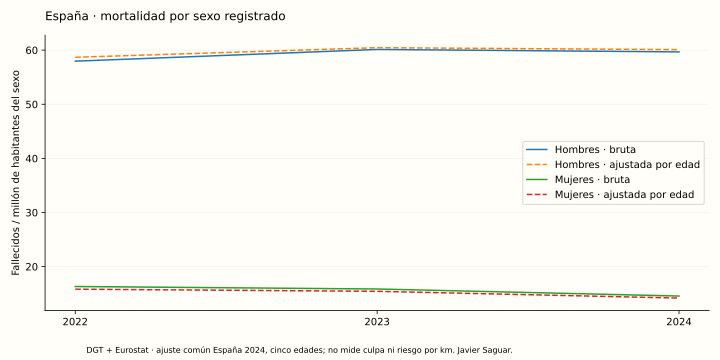

Standardization controls only five age bands. Unknown age excluded from adjusted point estimates; included in crude mortality. No fault or individual driving-risk inference.


In [5]:
persons = pd.read_csv(TABLES / "dgt_demographics.csv")
rates = pd.read_csv(TABLES / "spain_sex_rates.csv")
weights = pd.read_csv(TABLES / "spain_age_population.csv")
print(rates.to_string(index=False))
print(weights[(weights.year == 2024) & weights.sex.eq("M")][["age_band", "standard_weight_2024"]].to_string(index=False))
quality = json.loads((TABLES / "demographics_quality.json").read_text())
print(json.dumps(quality["source_notes"], ensure_ascii=False, indent=2))
assert persons[(persons.year == 2024) & persons.zone.eq("Urbana") & persons.role.eq("all_victims") & persons.category.eq("Bicicleta")].fatalities.isna().all()
display(SVG(filename=str(ROOT / "outputs/figures/spain_sex_mortality.svg")))
print("Standardization controls only five age bands. Unknown age excluded from adjusted point estimates; included in crude mortality. No fault or individual driving-risk inference.")

## Tipos de accidente y vehículos: volumen, gravedad y falta de exposición

                                    category  crashes  fatal_crash_pct    lower    upper  small_sample
                              Fronto-lateral    22176         0.707973 0.605840 0.827180         False
                                 Por alcance    17279         0.746571 0.628716 0.886321         False
                        Atropello a personas    12491         2.409735 2.155081 2.693652         False
                                     Lateral     8851         0.632697 0.487581 0.820646         False
                                       Caída     8454         0.520464 0.387950 0.697924         False
  Salida de la vía por la derecha, otro tipo     4805         2.060354 1.695334 2.501965         False
                      Otro tipo de accidente     4618         0.822867 0.600111 1.127371         False
                                      Vuelco     3664         0.818777 0.574137 1.166436         False
                                     Frontal     3329         7.389606 6.

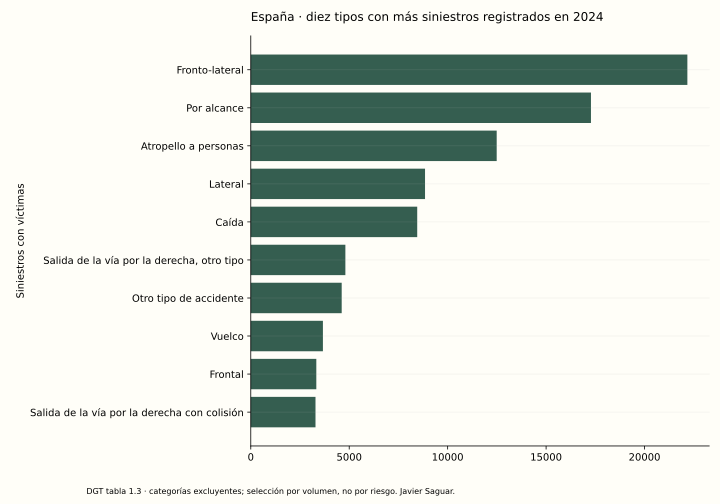

Conditional Wilson intervals use accident counts, not person deaths. Vehicle age counts lack age-specific fleet or distance denominators.


In [6]:
collision = pd.read_csv(TABLES / "collision_analysis.csv")
vehicles = pd.read_csv(TABLES / "vehicle_age_analysis.csv")
latest = collision[(collision.year == 2024) & collision.zone.eq("Total") & ~collision.is_total]
print(latest.nlargest(10, "crashes")[["category", "crashes", "fatal_crash_pct", "lower", "upper", "small_sample"]].to_string(index=False))
print(vehicles[(vehicles.year == 2024) & vehicles.zone.eq("Total") & vehicles.category.eq("Total")][["age", "vehicles", "share_all_pct"]].to_string(index=False))
print(json.loads((TABLES / "extended_analysis.json").read_text())["vehicle_type_source_note"])
display(SVG(filename=str(ROOT / "outputs/figures/spain_collision_categories.svg")))
print("Conditional Wilson intervals use accident counts, not person deaths. Vehicle age counts lack age-specific fleet or distance denominators.")

## Europa: panel denso, categorías anidadas y banderas originales

In [7]:
europe = pd.read_csv(TABLES / "europe_sex_users.csv")
assert len(europe) == 27 * 15 * 4 * 5
assert europe[europe.sex.eq("UNK")].population.isna().all()
print(europe[(europe.year == 2024) & europe.geo.eq("ES") & europe.pers_cat.eq("TOTAL")].to_string(index=False))
print("Observed death cells:", europe.fatalities.notna().sum(), "Compatible rate cells:", europe.included.sum())
print("Unknown sex remains visible without an invented denominator. Never add TOTAL to its component roles or sexes. Country rates are crude, not age-standardized.")

geo sex pers_cat  fatalities  fatalities_status  population population_status  year country  fatalities_per_million     lower     upper  included
 ES   T    TOTAL      1785.0                NaN  48619695.0               NaN  2024   Spain               36.713517 35.029923 38.457116      True
 ES   M    TOTAL      1422.0                NaN  23826871.0               NaN  2024   Spain               59.680518 56.618537 62.865058      True
 ES   F    TOTAL       361.0                NaN  24792824.0               NaN  2024   Spain               14.560665 13.097205 16.142929      True
 ES UNK    TOTAL         2.0                NaN         NaN               NaN  2024   Spain                     NaN       NaN       NaN     False
Observed death cells: 7846 Compatible rate cells: 5861
Unknown sex remains visible without an invented denominator. Never add TOTAL to its component roles or sexes. Country rates are crude, not age-standardized.
